<a href="https://colab.research.google.com/github/kny1209/test2/blob/main/AI/%EA%B0%95%EC%9D%98_8%EA%B8%B0_AI%EC%9D%91%EC%9A%A9_1%EC%B0%A8%EC%8B%9C_02_OpenCV%20%EC%83%89%EC%83%81%EC%9D%98%20%EA%B2%80%EC%B6%9C%20%EB%B0%8F%20%ED%9E%88%EC%8A%A4%ED%86%A0%EA%B7%B8%EB%9E%A8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
path = '/content/drive/MyDrive//wafer.jpg'

1. 색상에 대해서 히스토그램 그리기

2. 색상에 대해서 마스크 적용하기

In [3]:
import os
import numpy as np
import cv2

import matplotlib.pyplot as plt

In [6]:
src = cv2.imread(path)

array([[[162, 162, 162],
        [125, 125, 125],
        [135, 135, 135],
        ...,
        [115, 115, 115],
        [110, 110, 110],
        [162, 162, 162]],

       [[139, 139, 139],
        [ 74,  74,  74],
        [ 74,  74,  74],
        ...,
        [  1,   1,   1],
        [ 12,  12,  12],
        [103, 103, 103]],

       [[121, 121, 121],
        [ 22,  22,  22],
        [ 20,  20,  20],
        ...,
        [  0,   0,   0],
        [  6,   6,   6],
        [113, 113, 113]],

       ...,

       [[119, 119, 119],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  2,   2,   2],
        [  0,   0,   0],
        [113, 113, 113]],

       [[103, 103, 103],
        [ 13,  13,  13],
        [  4,   4,   4],
        ...,
        [  3,   3,   3],
        [  7,   7,   7],
        [106, 106, 106]],

       [[162, 162, 162],
        [109, 109, 109],
        [105, 105, 105],
        ...,
        [115, 115, 115],
        [104, 104, 104],
        [163, 163, 163]]], dtype=uint8)
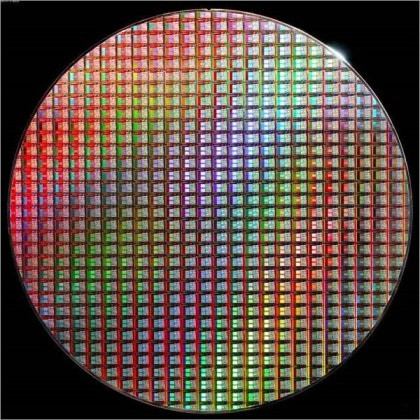

In [10]:
cv2.cvtColor(src, cv2.COLOR_BGR2RGB)

In [11]:
src = cv2.cvtColor(src, cv2.COLOR_BGR2GRAY)

array([[162, 125, 135, ..., 115, 110, 162],
       [139,  74,  74, ...,   1,  12, 103],
       [121,  22,  20, ...,   0,   6, 113],
       ...,
       [119,   0,   0, ...,   2,   0, 113],
       [103,  13,   4, ...,   3,   7, 106],
       [162, 109, 105, ..., 115, 104, 163]], dtype=uint8)
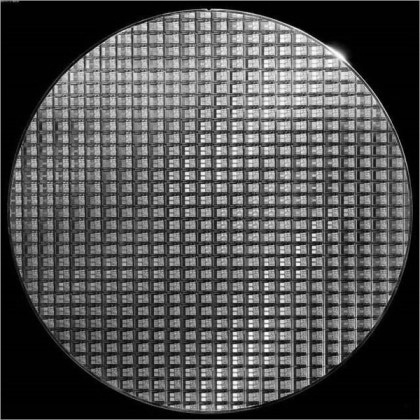

In [18]:
src

In [21]:
# cv2.calcHist() 히스토그램 계산 함수
hist = cv2.calcHist([src], [0], None, [256], [0, 256])
# 0번 채널, 마스크 설정 None(전체 이미지 사용)
# [256] : bin (계급구간) 개수 (0-255 총 256개 구간), 픽셀 범위 (0-255))

hist[250]
# 밝기의 값이 250인 pixel 개수

array([13.], dtype=float32)

In [22]:
print(hist[0])  # 검은 구간
print(hist[255])    # 하얀 구간

# 이 이미지는 검정 투성이
# 보정한다면 명도(빛의 밝기) 높이고,
# 컬러사진이라면 채도를 좊이는 작업이 필요함

[10105.]
[0.]


In [23]:
hist[0,0]
# 행렬의 가장 첫번째 값

np.float32(10105.0)

In [24]:
# x 좌표 (pixel 값 범위 0-255)
# channel : 분석할 채널 정보 (ex : grayscale[0] 지정)
# histSize : 히스토그램 구간 수 (0-255 : 256개 구간)
# histRange : pixel 값 범위 (0-255)

hist_size = [256]
hist_range = [0,256]
# 파이썬 range 범위 지정할 때 마지막 뒷 숫자는 미포함

#opencv 함수
hist = cv2.calcHist([src], [0], None, hist_size, hist_range)
# (이미지, 채널, None, x가 몇 개로 나누어져 있는가, x 범위)

In [28]:
hist_max = np.max(hist)
hist_max
# 어느 픽셀이 가장 많이 있는지(최대값 카운트)

np.float32(26606.0)

In [29]:
# 컴퓨터 입장에서 생각
# y값이 클수록 아래로 / 작을수록 위로
# 컴퓨터는 y가 아래로 늘어남
# 막대를 위로 올리려면, 전체 높이(100)이라면, 전체 높이에서 뺌

# 1단계 : 현재 밝기 값의 픽셀 개수
x = 0 # 검은색
hist[x,0]
# np.float32(10105.0) >> 10105개
# bias[0,0] 0번 (검은색) 인덱스는 픽셀 몇 개? > 10105개

np.float32(10105.0)

In [30]:
# 2단계 : 최대값 대비 비율 (0-1 사이)
# 3단계 : 퍼센트로 변환 (백분율, 0-100)
hist[x,0] * 100 / hist_max

np.float32(37.980156)

In [31]:
# 4단계 : 점수로 변환
int(hist[x,0] * 100 / hist_max)

37

In [32]:
# 5단계 : y좌표 계산 (아래에서 위)
# 100에서 뺴는 이유 : 컴퓨터는 y축이 뒤집혀 있음
100 - int(hist[x,0] * 100 / hist_max)

63

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], dtype=uint8)
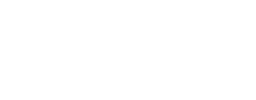

In [35]:
# 그래프 그릴 도화지
# 256(흰색) 채워진 100*256 도화지 준비
np.full((100,256),255, dtype=np.uint8)

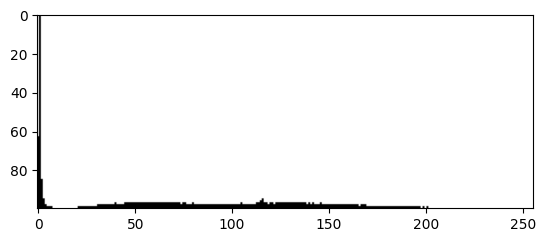

In [37]:
image_bg = np.full((100,256),255, dtype=np.uint8)

for x in range(256):
    # 시작점 pt1
    pt1 = (x, 100)
    # 컴퓨터는 y축이 뒤집혀 있음, 높이가 100인 경우, 디지털 100 = 사람이 생각하는 0

    # 끝점 pt2
    pt2 = (x, 100 - int(hist[x, 0] * 100 / hist_max))

    # cv2.line(이미지, 시작점, 끝점, 색상)
    cv2.line(image_bg, pt1, pt2, 0)

plt.imshow(image_bg, cmap='gray')
plt.show()

pt(x, 100) 의미
- (x=0, 100) = (0, 100) (밝기 0 (왼쪽 끝) 아래쪽)
- x=50 >> (50, 100) (밝기 50 위치에서 아래쪽)
- x =100 >> (100, 100) (밝기 100 위치에서 아래쪽)

일반적으로 히스토그램 (밝기, 개수) 형태

가로축 (x축) : pixel 밝기 값 위치
- x = 0 (아주 어두운 픽셀)
- x = 128 (중간 밝기 픽셀)
- x = 255 (아주 밝은 픽셀)

세로축 (y축) 픽셀의 개수

마스트 (색깔 마스크)

array([[[162, 162, 162],
        [125, 125, 125],
        [135, 135, 135],
        ...,
        [115, 115, 115],
        [110, 110, 110],
        [162, 162, 162]],

       [[139, 139, 139],
        [ 74,  74,  74],
        [ 74,  74,  74],
        ...,
        [  1,   1,   1],
        [ 12,  12,  12],
        [103, 103, 103]],

       [[121, 121, 121],
        [ 22,  22,  22],
        [ 20,  20,  20],
        ...,
        [  0,   0,   0],
        [  6,   6,   6],
        [113, 113, 113]],

       ...,

       [[119, 119, 119],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  2,   2,   2],
        [  0,   0,   0],
        [113, 113, 113]],

       [[103, 103, 103],
        [ 13,  13,  13],
        [  4,   4,   4],
        ...,
        [  3,   3,   3],
        [  7,   7,   7],
        [106, 106, 106]],

       [[162, 162, 162],
        [109, 109, 109],
        [105, 105, 105],
        ...,
        [115, 115, 115],
        [104, 104, 104],
        [163, 163, 163]]], dtype=uint8)
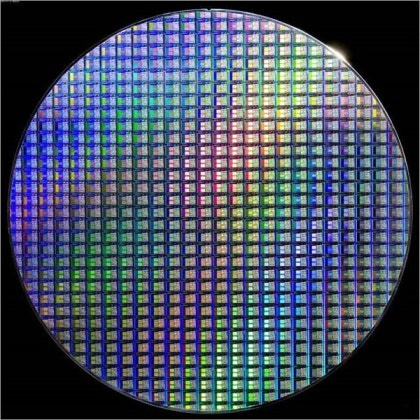

In [38]:
# 색공간(HSV)

cv2.imread(path)

array([[[162, 162, 162],
        [125, 125, 125],
        [135, 135, 135],
        ...,
        [115, 115, 115],
        [110, 110, 110],
        [162, 162, 162]],

       [[139, 139, 139],
        [ 74,  74,  74],
        [ 74,  74,  74],
        ...,
        [  1,   1,   1],
        [ 12,  12,  12],
        [103, 103, 103]],

       [[121, 121, 121],
        [ 22,  22,  22],
        [ 20,  20,  20],
        ...,
        [  0,   0,   0],
        [  6,   6,   6],
        [113, 113, 113]],

       ...,

       [[119, 119, 119],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  2,   2,   2],
        [  0,   0,   0],
        [113, 113, 113]],

       [[103, 103, 103],
        [ 13,  13,  13],
        [  4,   4,   4],
        ...,
        [  3,   3,   3],
        [  7,   7,   7],
        [106, 106, 106]],

       [[162, 162, 162],
        [109, 109, 109],
        [105, 105, 105],
        ...,
        [115, 115, 115],
        [104, 104, 104],
        [163, 163, 163]]], dtype=uint8)
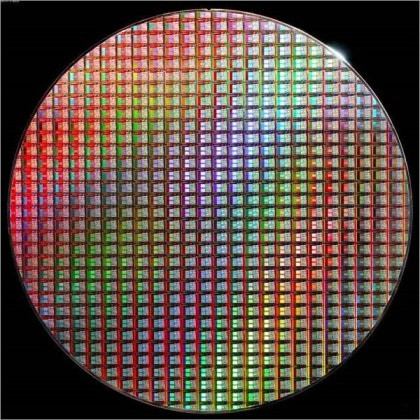

In [39]:
image = cv2.imread(path)
cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

array([[[  0,   0, 162],
        [  0,   0, 125],
        [  0,   0, 135],
        ...,
        [  0,   0, 115],
        [  0,   0, 110],
        [  0,   0, 162]],

       [[  0,   0, 139],
        [  0,   0,  74],
        [  0,   0,  74],
        ...,
        [  0,   0,   1],
        [  0,   0,  12],
        [  0,   0, 103]],

       [[  0,   0, 121],
        [  0,   0,  22],
        [  0,   0,  20],
        ...,
        [  0,   0,   0],
        [  0,   0,   6],
        [  0,   0, 113]],

       ...,

       [[  0,   0, 119],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   2],
        [  0,   0,   0],
        [  0,   0, 113]],

       [[  0,   0, 103],
        [  0,   0,  13],
        [  0,   0,   4],
        ...,
        [  0,   0,   3],
        [  0,   0,   7],
        [  0,   0, 106]],

       [[  0,   0, 162],
        [  0,   0, 109],
        [  0,   0, 105],
        ...,
        [  0,   0, 115],
        [  0,   0, 104],
        [  0,   0, 163]]], dtype=uint8)
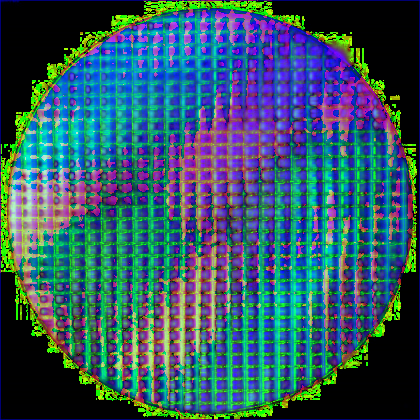

In [40]:
cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
# HSV (Hue, Sturation, Value 색상, 채도, 명도)
# >> 색상 분리하기 위해

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)
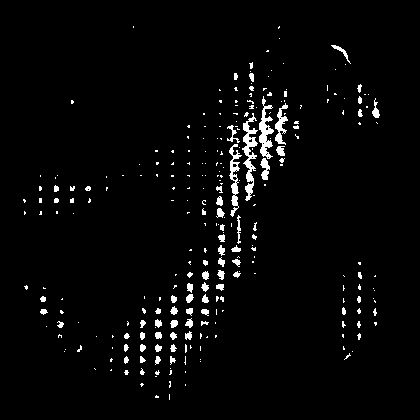

In [41]:
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# 파란색만 추출하고싶음
# 파란색 범위 (2개) 내가 지정

lower_blue = np.array([90, 50, 50])
hifg_blue = np.array([130, 255, 255])

# 마스크 색상
cv2.inRange(hsv, lower_blue, hifg_blue)

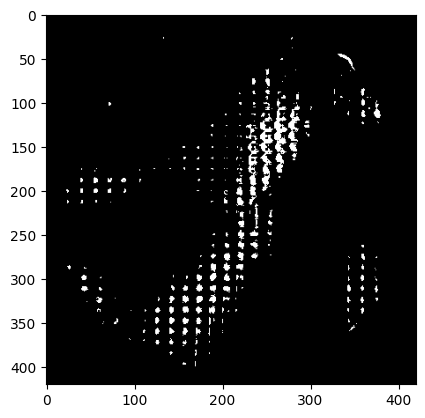

In [43]:
mask = cv2.inRange(hsv, lower_blue, hifg_blue)
# low-high 사이에 있는 값은 휜색 검은색

plt.imshow(mask, cmap='gray')
plt.show()

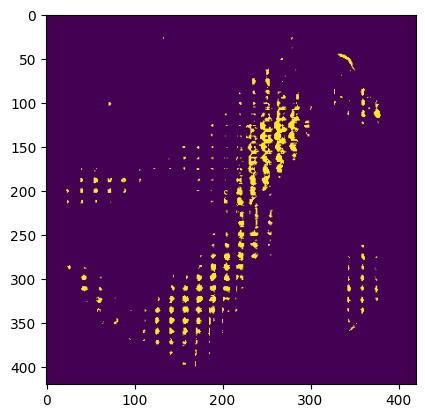

In [44]:
plt.imshow(mask)
plt.show()

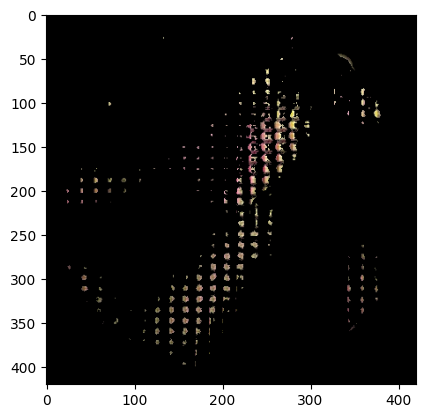

In [47]:
# AND 연산사
# (mask) 해당하는 흰색 부분만 남기고 싶음
result = cv2.bitwise_and(image, image, mask=mask)

plt.imshow(result)
plt.show()

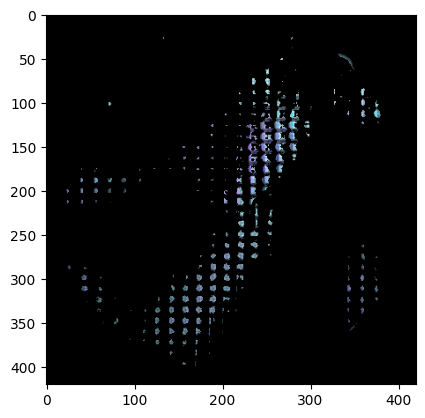

In [48]:
result = cv2.bitwise_and(image, image, mask=mask)

dst = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

plt.imshow(dst)
plt.show()

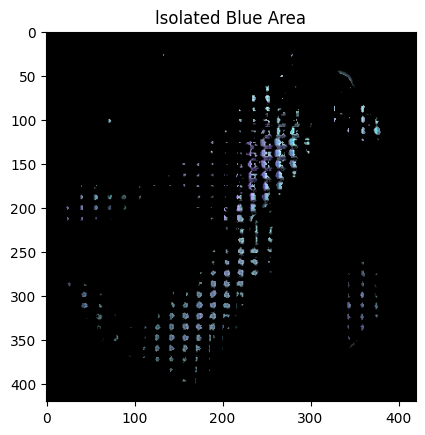

In [53]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread(path)
src = image.copy()
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

lower_blue = np.array([90, 50, 50])
hifg_blue = np.array([130, 255, 255])

mask = cv2.inRange(hsv, lower_blue, hifg_blue)

dst = cv2.bitwise_and(src, src, mask=mask)

dst_rgb = cv2.cvtColor(dst, cv2.COLOR_BGR2RGB)

plt.imshow(dst_rgb)
plt.title('lsolated Blue Area')
plt.show()